In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import numpy as np

In [2]:
sales_df =  pd.read_csv("retail_sales_4500_ghana.csv")

In [3]:
#previewing the data
sales_df.head()

,Date,Product,Category,Quantity,Price,Sales,Customer_ID,Region,Payment_Method,Customer_Type,Discount
0,2023-01-01,Smartphone,Electronics,1,884.59,751.90,CUST1965,Greater Accra,Card,Retail,0.15
1,2023-01-01,Mouse,Accessories,10,18.76,153.83,CUST1712,Greater Accra,Cash,Wholesale,0.18
2,2023-01-02,USB Drive,Accessories,4,15.21,58.41,CUST1968,Central,Cash,Retail,0.04
3,2023-01-02,Phone Case,Accessories,1,28.13,27.29,CUST1685,Greater Accra,Cash,Retail,0.03
4,2023-01-02,Keyboard,Accessories,7,91.28,549.51,CUST1830,Greater Accra,Cash,Wholesale,0.14


In [4]:
#previewing the data
sales_df.tail()

,Date,Product,Category,Quantity,Price,Sales,Customer_ID,Region,Payment_Method,Customer_Type,Discount
4495,2026-09-15,USB Drive,Accessories,2,31.48,57.29,CUST1801,Volta,Mobile Money,Retail,0.09
4496,2026-09-15,USB Drive,Accessories,1,30.26,28.14,CUST1645,Western,Mobile Money,Retail,0.07
4497,2026-09-15,Tablet,Electronics,3,495.96,1324.21,CUST1799,Western,Mobile Money,Retail,0.11
4498,2026-09-16,Laptop,Electronics,4,1469.98,5821.12,CUST1754,Northern,Card,Retail,0.01
4499,2026-09-16,Desk Lamp,Furniture,3,36.97,100.93,CUST1005,Volta,Mobile Money,Retail,0.09


In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4500 non-null   object 
 1   Product         4500 non-null   object 
 2   Category        4500 non-null   object 
 3   Quantity        4500 non-null   int64  
 4   Price           4500 non-null   float64
 5   Sales           4500 non-null   float64
 6   Customer_ID     4500 non-null   object 
 7   Region          4500 non-null   object 
 8   Payment_Method  4500 non-null   object 
 9   Customer_Type   4500 non-null   object 
 10  Discount        4500 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 386.8+ KB


In [6]:
sales_df.columns

Index(['Date', 'Product', 'Category', 'Quantity', 'Price', 'Sales',
       'Customer_ID', 'Region', 'Payment_Method', 'Customer_Type', 'Discount'],
      dtype='object')

In [7]:
#rearranging the appearance of columns in the dataset
sales_df = sales_df[["Date","Customer_ID","Customer_Type","Region","Payment_Method","Category","Product","Quantity","Price","Discount","Sales"]]
sales_df.head()

,Date,Customer_ID,Customer_Type,Region,Payment_Method,Category,Product,Quantity,Price,Discount,Sales
0,2023-01-01,CUST1965,Retail,Greater Accra,Card,Electronics,Smartphone,1,884.59,0.15,751.90
1,2023-01-01,CUST1712,Wholesale,Greater Accra,Cash,Accessories,Mouse,10,18.76,0.18,153.83
2,2023-01-02,CUST1968,Retail,Central,Cash,Accessories,USB Drive,4,15.21,0.04,58.41
3,2023-01-02,CUST1685,Retail,Greater Accra,Cash,Accessories,Phone Case,1,28.13,0.03,27.29
4,2023-01-02,CUST1830,Wholesale,Greater Accra,Cash,Accessories,Keyboard,7,91.28,0.14,549.51


In [8]:
sales_df[sales_df.duplicated()]

,Date,Customer_ID,Customer_Type,Region,Payment_Method,Category,Product,Quantity,Price,Discount,Sales


In [9]:
sales_df.select_dtypes("object")

,Date,Customer_ID,Customer_Type,Region,Payment_Method,Category,Product
0,2023-01-01,CUST1965,Retail,Greater Accra,Card,Electronics,Smartphone
1,2023-01-01,CUST1712,Wholesale,Greater Accra,Cash,Accessories,Mouse
2,2023-01-02,CUST1968,Retail,Central,Cash,Accessories,USB Drive
3,2023-01-02,CUST1685,Retail,Greater Accra,Cash,Accessories,Phone Case
4,2023-01-02,CUST1830,Wholesale,Greater Accra,Cash,Accessories,Keyboard
...,...,...,...,...,...,...,...
4495,2026-09-15,CUST1801,Retail,Volta,Mobile Money,Accessories,USB Drive
4496,2026-09-15,CUST1645,Retail,Western,Mobile Money,Accessories,USB Drive
4497,2026-09-15,CUST1799,Retail,Western,Mobile Money,Electronics,Tablet
4498,2026-09-16,CUST1754,Retail,Northern,Card,Electronics,Laptop


In [10]:
categorical_cols = ["Customer_Type","Region","Payment_Method","Category","Product"]

for col in categorical_cols:
    print(f"{col}: {sales_df[col].unique()}")

Customer_Type: ['Retail' 'Wholesale']
Region: ['Greater Accra' 'Central' 'Bono' 'Northern' 'Western' 'Ashanti' 'Eastern'
 'Volta']
Payment_Method: ['Card' 'Cash' 'Mobile Money' 'Bank Transfer']
Category: ['Electronics' 'Accessories' 'Furniture']
Product: ['Smartphone' 'Mouse' 'USB Drive' 'Phone Case' 'Keyboard' 'Laptop'
 'Tablet' 'Monitor' 'Webcam' 'Desk Lamp' 'Headphones' 'Office Chair'
 'Desk' 'Bookshelf' 'Printer']


In [11]:
sales_df.select_dtypes("number")

,Quantity,Price,Discount,Sales
0,1,884.59,0.15,751.90
1,10,18.76,0.18,153.83
2,4,15.21,0.04,58.41
3,1,28.13,0.03,27.29
4,7,91.28,0.14,549.51
...,...,...,...,...
4495,2,31.48,0.09,57.29
4496,1,30.26,0.07,28.14
4497,3,495.96,0.11,1324.21
4498,4,1469.98,0.01,5821.12


In [12]:
numerical_cols = ["Quantity","Price","Discount","Sales"]

for col in numerical_cols:
    print(f"{col} : {sales_df[col].min()}")
  

Quantity : 1
Price : 10.05
Discount : 0.0
Sales : 8.91


In [13]:
# Cross Field Validation
sales_df["Actual_Cost"] = (sales_df["Price"] * sales_df["Quantity"])
sales_df["Discount_price"] = (sales_df["Discount"]*sales_df["Actual_Cost"])
consistent = np.isclose(sales_df["Actual_Cost"], sales_df["Sales"] + sales_df["Discount_price"], atol = 0.01)

In [14]:
# checking the number of consistent transactions
sales_df[consistent].shape

(4500, 13)

In [15]:
# checking the number of inconsistent transactions
sales_df[~consistent].shape

(0, 13)

In [16]:
#checking for outliers
q1 = sales_df["Sales"].quantile(0.25)
q3 = sales_df["Sales"].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5*iqr
lower_limit = q1 - 1.5*iqr

outliers = sales_df[(sales_df["Sales"] < lower_limit) & (sales_df["Sales"] > upper_limit)]
outliers

,Date,Customer_ID,Customer_Type,Region,Payment_Method,Category,Product,Quantity,Price,Discount,Sales,Actual_Cost,Discount_price


How many transactions?

In [17]:
total_transactions = len(sales_df)
print(f"{total_transactions:,} transactions")

4,500 transactions


What are the products?

In [18]:
sales_df["Product"].unique()

array(['Smartphone', 'Mouse', 'USB Drive', 'Phone Case', 'Keyboard',
       'Laptop', 'Tablet', 'Monitor', 'Webcam', 'Desk Lamp', 'Headphones',
       'Office Chair', 'Desk', 'Bookshelf', 'Printer'], dtype=object)

How many categories?

In [19]:
print(f"Number of Categories: {sales_df["Category"].nunique()}")

Number of Categories: 3


What is the total revenue?

In [20]:
total_revenue = sales_df["Sales"].sum()
print(f"Total Revenue: {total_revenue:,}")

Total Revenue: 3,401,067.24


What is the total quantity sold?

In [21]:
total_quantity = sales_df["Quantity"].sum()
print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 17,882


What is the best selling product?

In [22]:
product_sales = (sales_df.groupby("Product")["Sales"].sum().sort_values(ascending = False))
product_sales

Product
Laptop          726882.25
Smartphone      719011.15
Tablet          324525.88
Monitor         315289.68
Desk            277780.46
Office Chair    209458.19
Printer         172916.40
Headphones      128126.58
Bookshelf       109455.29
Keyboard        100758.85
Webcam           95691.56
Desk Lamp        66411.52
Phone Case       58650.34
Mouse            55742.51
USB Drive        40366.58
Name: Sales, dtype: float64

In [23]:
best_selling_product = product_sales.idxmax()
best_selling_product_sales = product_sales.max()
print(f"{best_selling_product} : {best_selling_product_sales:,}")

Laptop : 726,882.25


Which product sold the most unit?

In [24]:
product_quantity = (sales_df.groupby("Product")["Quantity"].sum()
                            .sort_values(ascending = False))
product_quantity 

Product
Phone Case      2376
Mouse           1906
USB Drive       1798
Keyboard        1564
Headphones      1349
Desk Lamp       1341
Monitor         1067
Smartphone      1067
Office Chair    1010
Webcam           973
Tablet           774
Desk             759
Laptop           719
Bookshelf        612
Printer          567
Name: Quantity, dtype: int64

In [25]:
highest_quantity_product = product_quantity.idxmax()
highest_quantity = product_quantity.max()
print(f"{highest_quantity_product}: {highest_quantity} units sold")

Phone Case: 2376 units sold


Which category generated the most revenue?

In [26]:
category_sales = sales_df.groupby("Category")["Sales"].sum().sort_values()
category_sales


Category
Accessories     255518.28
Furniture       663105.46
Electronics    2482443.50
Name: Sales, dtype: float64

In [27]:
best_selling_category = category_sales.idxmax()
best_sales = category_sales.max()
print(f"{best_selling_category}: {best_sales:,}")

Electronics: 2,482,443.5


What is the average transaction value?

In [28]:
average_sales = sales_df["Sales"].median()
average_sales

np.float64(228.85)

What is the highest sales?

In [29]:
highest_sales = sales_df["Sales"].max()
highest_sales

np.float64(14111.06)

What is the lowest sale?

In [30]:
lowest_sales = sales_df["Sales"].min()
lowest_sales 

np.float64(8.91)

In [31]:
# Summary table for Products
product_summary_table = sales_df.groupby("Product").agg(
    Total_Sales = ("Sales", "sum"),
    Total_Quantity = ("Quantity", "sum"),
    Average_Sales = ("Sales", "median"),
    Transactions = ("Product", "count")

)
product_summary_table

,Total_Sales,Total_Quantity,Average_Sales,Transactions
Product,,,,
Bookshelf,109455.29,612,520.480,139
Desk,277780.46,759,1057.475,172
Desk Lamp,66411.52,1341,138.740,342
Headphones,128126.58,1349,268.280,333
Keyboard,100758.85,1564,183.090,375
Laptop,726882.25,719,2905.640,199
Monitor,315289.68,1067,928.950,259
Mouse,55742.51,1906,85.120,501
Office Chair,209458.19,1010,670.260,245


In [32]:
# Summary table for Category
category_summary_table = sales_df.groupby("Category").agg(
    Total_Sales = ("Sales", "sum"),
    Total_Quantity = ("Quantity", "sum"),
    Average_Sales = ("Sales", "median"),
    Transactions = ("Category", "count")

)
category_summary_table

,Total_Sales,Total_Quantity,Average_Sales,Transactions
Category,,,,
Accessories,255518.28,7644,82.26,1955
Electronics,2482443.50,6516,814.07,1647
Furniture,663105.46,3722,394.79,898


In [33]:
# Summary table for Region
region_summary_table = sales_df.groupby("Region").agg(
    Total_Sales = ("Sales", "sum"),
    Total_Quantity = ("Quantity", "sum"),
    Average_Sales = ("Sales", "median"),
    Transactions = ("Region", "count")

)
region_summary_table

,Total_Sales,Total_Quantity,Average_Sales,Transactions
Region,,,,
Ashanti,557333.17,3171,205.560,790
Bono,208925.62,1001,251.790,249
Central,250752.29,1440,189.850,371
Eastern,319840.66,1681,243.860,413
Greater Accra,1346373.43,6730,233.115,1722
Northern,242109.11,1090,238.170,282
Volta,166082.11,1081,234.580,246
Western,309650.85,1688,242.820,427


In [34]:
# Summary table for Customer Type
customer_type_summary_table = sales_df.groupby("Customer_Type").agg(
    Total_Sales = ("Sales", "sum"),
    Total_Quantity = ("Quantity", "sum"),
    Average_Sales = ("Sales", "median"),
    Transactions = ("Customer_Type", "count")

)
customer_type_summary_table

,Total_Sales,Total_Quantity,Average_Sales,Transactions
Customer_Type,,,,
Retail,2291885.16,11617,189.07,3697
Wholesale,1109182.08,6265,506.08,803


In [35]:
#converting date column into a timestamp
sales_df["Date"] = pd.to_datetime(sales_df["Date"])
sales_df["Month"] = sales_df["Date"].dt.month
sales_df["Year"] = sales_df["Date"].dt.year

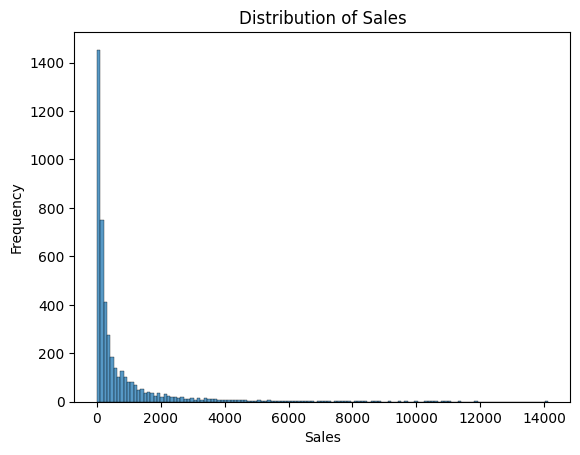

In [36]:
sns.histplot(data = sales_df, x= "Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

In [37]:
#daily sales
daily_sales = (sales_df.groupby("Date")[["Sales"]].sum())
daily_sales

,Sales
Date,
2023-01-01,905.73
2023-01-02,11007.02
2023-01-03,1247.55
2023-01-04,6553.46
2023-01-05,491.59
...,...
2026-09-12,5798.98
2026-09-13,140.18
2026-09-14,10866.40


In [38]:
#monthly sales
monthly_sales = sales_df.groupby(["Year", "Month"])["Sales"].sum()
monthly_sales

Year  Month
2023  1         48960.61
      2         59740.82
      3         63023.85
      4         87857.59
      5         83062.32
      6        102171.78
      7         80383.17
      8         89120.90
      9         71251.98
      10        69525.32
      11       101263.37
      12       146421.78
2024  1         60621.23
      2         47774.37
      3         74294.71
      4         60921.63
      5         88417.82
      6         61872.64
      7         97561.05
      8         33076.37
      9         67811.15
      10        71266.52
      11        88134.91
      12       156233.12
2025  1         44580.67
      2         61448.41
      3         66715.47
      4         46835.56
      5         65451.94
      6         82997.06
      7         79284.74
      8         75755.32
      9         74029.22
      10        93325.55
      11        98287.84
      12       161169.06
2026  1         26872.24
      2         50540.36
      3         62421.19
      4      

Is there a consistent upward trend?

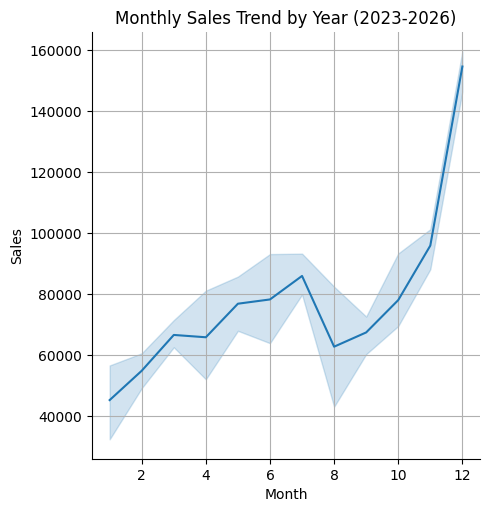

In [39]:

g = sns.relplot(data = monthly_sales.reset_index(), x = "Month", y = "Sales", kind = "line")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend by Year (2023-2026)")
#g.fig.suptitle("Monthly Sales Trend by Year (2023-2026)", y = 1.02, fontsize = 16, fontweight = "bold")
plt.grid()
plt.show()

Which month generated the highest revenue?

In [40]:
best_month = monthly_sales.idxmax()
best_month

(np.int32(2025), np.int32(12))

In [41]:
best_sales = monthly_sales.max()
print(best_sales)

161169.06


Which month had the biggest decline?

In [42]:
worst_month = monthly_sales.idxmin()
worst_month

(np.int32(2026), np.int32(1))

In [43]:
worst_sales = monthly_sales.min()
print(worst_sales)

26872.239999999998


In [44]:
monthly_growth = monthly_sales.pct_change()*100
monthly_growth.fillna(0)

Year  Month
2023  1          0.000000
      2         22.018128
      3          5.495455
      4         39.403718
      5         -5.458003
      6         23.006172
      7        -21.325468
      8         10.870099
      9        -20.050201
      10        -2.423315
      11        45.649628
      12        44.595010
2024  1        -58.598215
      2        -21.192015
      3         55.511648
      4        -18.000043
      5         45.133707
      6        -30.022432
      7         57.680438
      8        -66.096747
      9        105.013882
      10         5.095578
      11        23.669445
      12        77.265876
2025  1        -71.465289
      2         37.836443
      3          8.571516
      4        -29.798051
      5         39.748388
      6         26.806111
      7         -4.472833
      8         -4.451575
      9         -2.278520
      10        26.065829
      11         5.317183
      12        63.976602
2026  1        -83.326676
      2         88.076469


In [45]:
highest_growth = monthly_growth.max()
highest_monthly_growth = monthly_growth.idxmax()
print(f"{highest_monthly_growth}: {highest_growth}")

(np.int32(2024), np.int32(9)): 105.0138815111815


In [46]:
lowest_growth = monthly_growth.min()
lowest_growth
lowest_monthly_growth = monthly_growth.idxmin()
print(f"{lowest_monthly_growth}: {lowest_growth}")

(np.int32(2026), np.int32(1)): -83.3266757279592


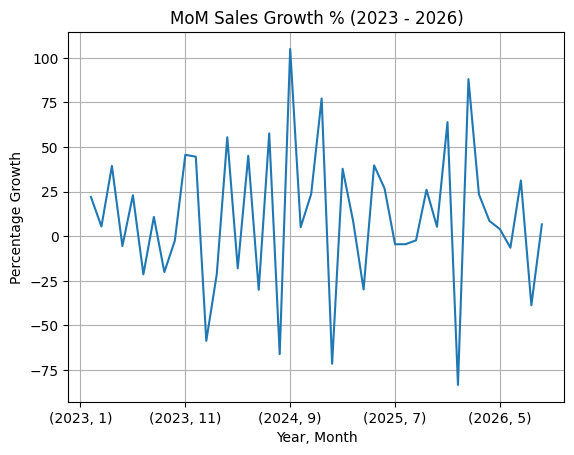

In [47]:
monthly_growth.plot(kind = "line")
plt.title("MoM Sales Growth % (2023 - 2026)")
plt.ylabel("Percentage Growth")
plt.xlabel("Year, Month")
plt.grid()
plt.show()

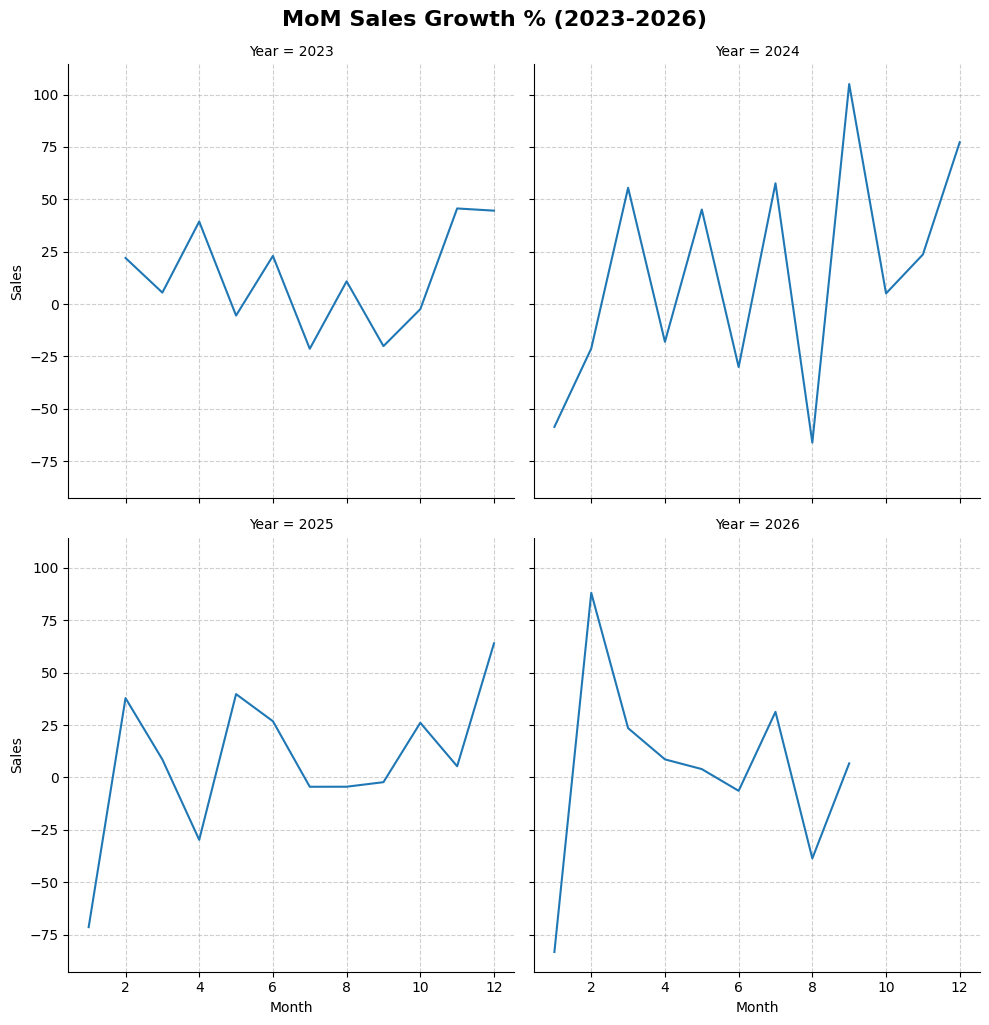

In [48]:
g = sns.relplot(data = monthly_growth.reset_index(), x = "Month", y = "Sales", col = "Year",col_wrap = 2, kind = "line")
plt.xlabel("Month")
plt.ylabel("Growth %")
g.fig.suptitle("MoM Sales Growth % (2023-2026)", y = 1.02, fontsize = 16, fontweight = "bold")
for ax in g.axes.flat:
    ax.grid(True, linestyle = "--", alpha = 0.6)
plt.show()

Which category drives growth?

In [49]:
yearly_sales_by_category = (sales_df.groupby(["Year","Category"])["Sales"].sum().unstack())
yearly_sales_by_category

Category,Accessories,Electronics,Furniture
Year,,,
2023,70218.83,698571.38,233993.28
2024,69433.43,678410.74,160141.35
2025,73821.45,705928.13,170131.26
2026,42044.57,399533.25,98839.57


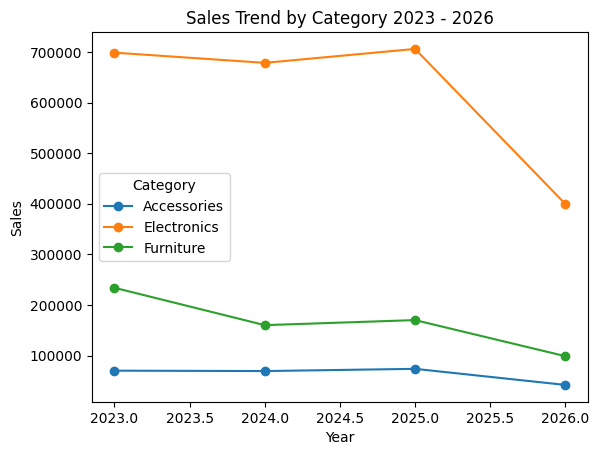

Category  Accessories  Electronics  Furniture
Year                                         
2023             0.00         0.00       0.00
2024          -785.40    -20160.64  -73851.93
2025          4388.02     27517.39    9989.91
2026        -31776.88   -306394.88  -71291.69


In [50]:
growth = yearly_sales_by_category.diff().fillna(0)

yearly_sales_by_category.plot(marker = "o")
plt.ylabel("Sales")
plt.title("Sales Trend by Category 2023 - 2026")
plt.show()

print(growth)

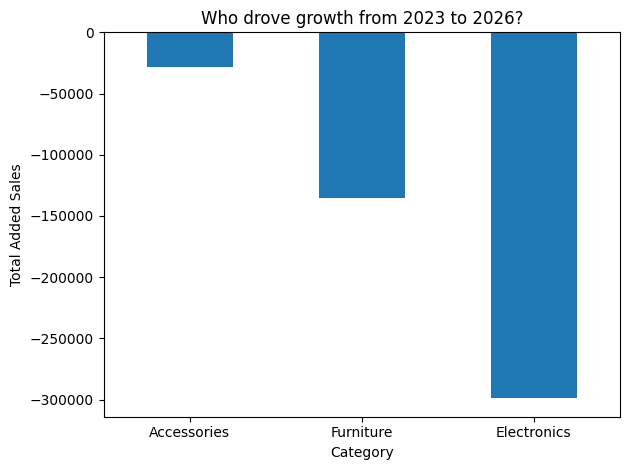

Category
Accessories    -28174.26
Furniture     -135153.71
Electronics   -299038.13
dtype: float64
 Therefore Electronics is driving decline from 2023 - 2026


In [51]:
total_growth = yearly_sales_by_category.loc[2026] - yearly_sales_by_category.loc[2023]

total_growth.sort_values(ascending = False).plot.bar()
plt.title("Who drove growth from 2023 to 2026?")
plt.ylabel("Total Added Sales")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

print(f"{total_growth.sort_values(ascending = False)}\n Therefore Electronics is driving decline from 2023 - 2026")

Are certain categories stronger during particular periods?

In [52]:
best_month = sales_df.groupby(["Category","Year" ,"Month"])["Sales"].sum().reset_index()

best_month = best_month.loc[best_month.groupby("Category")["Sales"].idxmax()]

best_month

,Category,Year,Month,Sales
11,Accessories,2023,12,13349.26
80,Electronics,2025,12,126269.90
101,Furniture,2023,12,34528.29


In [53]:
category_monthly = sales_df.groupby(["Year", "Month", "Category"])["Sales"].sum().unstack()
category_monthly

Category    Accessories  Electronics  Furniture
Year Month                                     
2023 1          6076.79     35172.83    7710.99
     2          3952.28     35029.19   20759.35
     3          5563.02     28703.46   28757.37
     4          5090.40     68544.92   14222.27
     5          5750.95     59383.60   17927.77
     6          6400.19     82096.66   13674.93
     7          6140.86     59238.86   15003.45
     8          4797.39     59302.16   25021.35
     9          4802.82     47527.08   18922.08
     10         3929.35     49952.10   15643.87
     11         4365.52     75076.29   21821.56
     12        13349.26     98544.23   34528.29
2024 1          5130.60     33647.00   21843.63
     2          5453.94     36179.78    6140.65
     3          6418.78     54910.99   12964.94
     4          5000.63     47180.58    8740.42
     5          4776.27     70108.51   13533.04
     6          3525.21     46623.43   11724.00
     7          4567.00     86279.62    6714.43
     8          4435.62     25185.25    3455.50
     9          7032.47     40472.56   20306.12
     10         4437.36     47610.14   19219.02
     11         7089.95     70518.69   10526.27
     12        11565.60    119694.19   24973.33
2025 1          3881.06     29023.46   11676.15
     2          6981.13     42967.41   11499.87
     3          4203.25     53622.08    8890.14
     4          6668.85     30233.15    9933.56
     5          4134.33     48047.13   13270.48
     6          5413.91     62277.30   15305.85
     7          9420.22     54056.01   15808.51
     8          5739.80     58119.68   11895.84
     9          3695.59     59609.76   10723.87
     10         5385.31     65467.86   22472.38
     11         6597.80     76234.39   15455.65
     12        11700.20    126269.90   23198.96
2026 1          4240.79     20177.91    2453.54
     2          4789.66     36348.68    9402.02
     3          6025.81     46819.12    9576.26
     4          5897.05     48303.74   13589.62
     5          5887.83     42921.26   21667.01
     6          3359.22     52892.42    9708.47
     7          3728.76     71951.88   10916.43
     8          5449.93     33987.13   13667.73
     9          2665.52     46131.11    7858.49

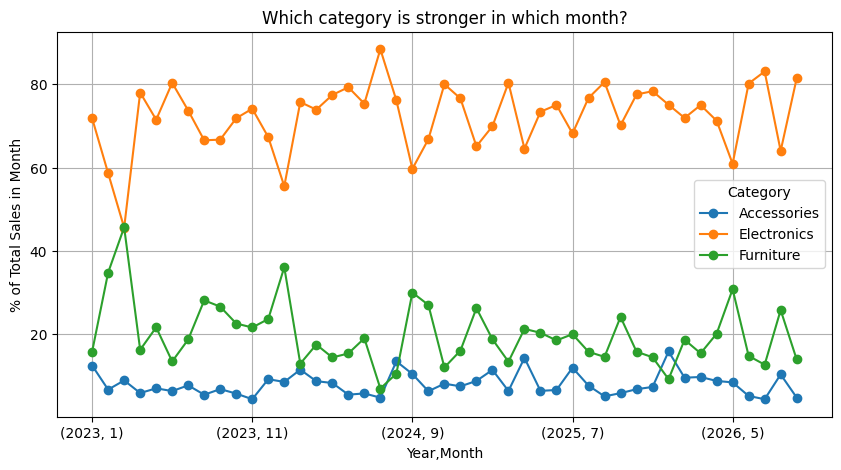

In [54]:
share = category_monthly.div(category_monthly.sum(axis =1), axis = 0) *100
share.plot(marker = "o",figsize = (10, 5))
plt.ylabel("% of Total Sales in Month")
plt.title("Which category is stronger in which month?")
plt.grid()
#plt.xticks(range(1, 13))
plt.show()

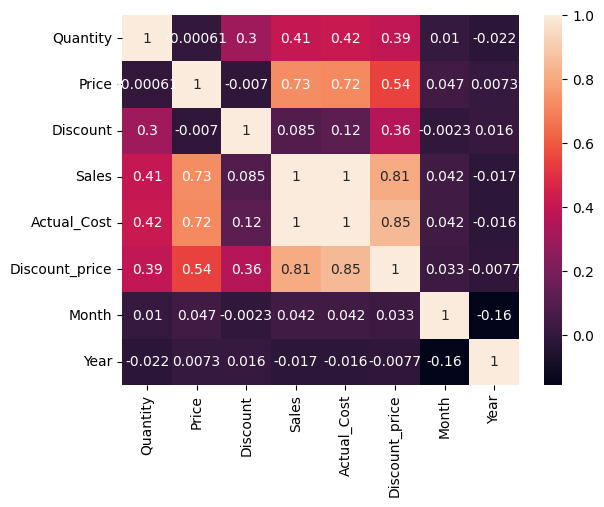

In [55]:
sns.heatmap(data = sales_df.corr(numeric_only = True), annot = True)

plt.show()